# Evaluation and Comparing

Fourth notebook in the split workflow. It loads outputs from the previous notebooks, writes the compact run summary, and creates model/KG comparison tables.


## 1. Configuration

In [1]:
from pathlib import Path

# -----------------------------------------------------------------------------
# Shared data folder.
# -----------------------------------------------------------------------------
# All files that are inputs to, outputs from, or shared between multiple models
# are stored in data/. Model-specific artifacts remain in their own folders.
DATA_DIR = Path("data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

# Input XML.
XML_PATH = DATA_DIR / "bookworm_09062026.xml"

# Shared preprocessing and training files used by the split workflow.
PAGES_CSV = DATA_DIR / "pages.csv"
CANDIDATE_EXAMPLES_CSV = DATA_DIR / "candidate_examples.csv"
LLM_LABELED_CANDIDATES_CSV = DATA_DIR / "candidate_examples_llm_labeled.csv"
TRAIN_CSV = DATA_DIR / "train.csv"
DEV_CSV = DATA_DIR / "dev.csv"
TEST_CSV = DATA_DIR / "test.csv"
MODEL_COMPARISON_CSV = DATA_DIR / "metrics_model_comparison.csv"
KG_MODEL_COMPARISON_CSV = DATA_DIR / "kg_model_comparison.csv"
RUN_SUMMARY_JSON = DATA_DIR / "model_run_summary.json"
PIPELINE_RUN_METADATA_JSON = DATA_DIR / "pipeline_run_metadata.json"

# Model-specific output folders.
BASELINE_DIR = Path("baseline")  # TF-IDF + Logistic Regression artifacts.
BILSTM_DIR = Path("bilstm")      # BiLSTM artifacts.
TRANSFORMER_DIR = Path("transformer")  # DistilBERT/transformer artifacts from 02.5_transformer_colab.ipynb.
BASELINE_DIR.mkdir(parents=True, exist_ok=True)
BILSTM_DIR.mkdir(parents=True, exist_ok=True)
TRANSFORMER_DIR.mkdir(parents=True, exist_ok=True)

# Relationship labels. "no_relation" is needed as the negative class.
RELATIONSHIPS = [
    "family",
    "romantic",
    "friend_ally",
    "service_retainer",
    "enemy_rival",
    "no_relation",
]

RANDOM_SEED = 42
EDGE_CONFIDENCE_THRESHOLD = 0.95  # predictions_all_best_baseline.csv

print(f"XML path: {XML_PATH.resolve()}")
print(f"Shared data folder: {DATA_DIR.resolve()}")
print(f"Baseline output folder: {BASELINE_DIR.resolve()}")
print(f"BiLSTM output folder: {BILSTM_DIR.resolve()}")
print(f"Transformer output folder: {TRANSFORMER_DIR.resolve()}")
print(f"Relationship labels: {RELATIONSHIPS}")


XML path: E:\Natural Language Processing\Project 2\data\bookworm_09062026.xml
Shared data folder: E:\Natural Language Processing\Project 2\data
Baseline output folder: E:\Natural Language Processing\Project 2\baseline
BiLSTM output folder: E:\Natural Language Processing\Project 2\bilstm
Transformer output folder: E:\Natural Language Processing\Project 2\transformer
Relationship labels: ['family', 'romantic', 'friend_ally', 'service_retainer', 'enemy_rival', 'no_relation']


## 2. Imports

In [2]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_colwidth", 140)
np.random.seed(RANDOM_SEED)


## Load outputs from the previous split notebooks

Run the data-pipeline, models, and graph-generation notebooks first. This cell restores the DataFrames and status variables needed for the summary and comparison tables.


In [3]:
def read_csv_or_empty(path: Path, columns: list[str] | None = None) -> pd.DataFrame:
    path = Path(path)
    if path.exists():
        return pd.read_csv(path)
    return pd.DataFrame(columns=columns or [])

def require_file(path: Path, upstream_notebook: str) -> Path:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing {path}. Run {upstream_notebook} first.")
    return path

pipeline_metadata = json.loads(PIPELINE_RUN_METADATA_JSON.read_text(encoding="utf-8")) if PIPELINE_RUN_METADATA_JSON.exists() else {}

# Core shared data produced by 01_data_pipeline.ipynb.
pages_df = pd.read_csv(require_file(PAGES_CSV, "01_data_pipeline.ipynb"))
candidate_source_csv = Path(pipeline_metadata.get("candidate_source_csv", CANDIDATE_EXAMPLES_CSV))
LABEL_SOURCE = pipeline_metadata.get("label_source", "weak_labels")
candidates_df = pd.read_csv(require_file(candidate_source_csv, "01_data_pipeline.ipynb"))

train_df = pd.read_csv(require_file(TRAIN_CSV, "01_data_pipeline.ipynb"))
dev_df = pd.read_csv(require_file(DEV_CSV, "01_data_pipeline.ipynb"))
test_df = pd.read_csv(require_file(TEST_CSV, "01_data_pipeline.ipynb"))
split_method = pipeline_metadata.get("split_method", "loaded_from_csv")

# Model outputs produced by 02_models.ipynb.
metrics_df = pd.read_csv(require_file(BASELINE_DIR / "metrics_baseline_variants.csv", "02_models.ipynb"))
if len(metrics_df):
    best_variant = str(metrics_df.iloc[0]["variant"])
    best_text_column = str(metrics_df.iloc[0]["text_column"])
else:
    best_variant = "not_available"
    best_text_column = "not_available"

bilstm_metrics_path = BILSTM_DIR / "metrics_bilstm.csv"
if bilstm_metrics_path.exists():
    loaded_bilstm_metrics_df = pd.read_csv(bilstm_metrics_path)
    if len(loaded_bilstm_metrics_df):
        bilstm_metrics_df = loaded_bilstm_metrics_df

transformer_metrics_path = TRANSFORMER_DIR / "metrics_transformer.csv"
if transformer_metrics_path.exists():
    loaded_transformer_metrics_df = pd.read_csv(transformer_metrics_path)
    if len(loaded_transformer_metrics_df):
        transformer_metrics_df = loaded_transformer_metrics_df

# Graph outputs produced by 03_graph_generation.ipynb.
kg_edges_df = read_csv_or_empty(BASELINE_DIR / "kg_edges_best_baseline.csv")
kg_edges_bilstm_path = BILSTM_DIR / "kg_edges_bilstm.csv"
if kg_edges_bilstm_path.exists():
    kg_edges_bilstm_df = pd.read_csv(kg_edges_bilstm_path)

kg_edges_transformer_path = TRANSFORMER_DIR / "kg_edges_transformer.csv"
if kg_edges_transformer_path.exists():
    kg_edges_transformer_df = pd.read_csv(kg_edges_transformer_path)

graph_path = BASELINE_DIR / "kg_tfidf_logreg_best_baseline.html"
if graph_path.exists():
    graph_status = "existing_file"

graph_path_bilstm = BILSTM_DIR / "kg_bilstm.html"
if graph_path_bilstm.exists():
    graph_status_bilstm = "existing_file"

graph_path_transformer = TRANSFORMER_DIR / "kg_transformer.html"
if graph_path_transformer.exists():
    graph_status_transformer = "existing_file"

print(f"Loaded data: pages={len(pages_df):,}, candidates={len(candidates_df):,}, train/dev/test={len(train_df):,}/{len(dev_df):,}/{len(test_df):,}; label_source={LABEL_SOURCE}; split_method={split_method}")
print(f"Candidate source CSV: {candidate_source_csv}")
print(f"Loaded baseline metrics: {len(metrics_df):,} row(s); best variant: {best_variant}")
print(f"Loaded baseline KG edges: {len(kg_edges_df):,}")
if "bilstm_metrics_df" in globals():
    print(f"Loaded BiLSTM metrics: {len(bilstm_metrics_df):,} row(s)")
if "transformer_metrics_df" in globals():
    print(f"Loaded transformer metrics: {len(transformer_metrics_df):,} row(s)")
if "kg_edges_bilstm_df" in globals():
    print(f"Loaded BiLSTM KG edges: {len(kg_edges_bilstm_df):,}")
if "kg_edges_transformer_df" in globals():
    print(f"Loaded transformer KG edges: {len(kg_edges_transformer_df):,}")


Loaded data: pages=257, candidates=6,031, train/dev/test=4,251/915/865; label_source=llm_judge; split_method=grouped_by_pair
Candidate source CSV: data\candidate_examples_llm_labeled.csv
Loaded baseline metrics: 2 row(s); best variant: tfidf_logreg_basic
Loaded baseline KG edges: 653
Loaded BiLSTM metrics: 1 row(s)
Loaded transformer metrics: 1 row(s)
Loaded BiLSTM KG edges: 976
Loaded transformer KG edges: 1,297


## 16. Output summary

This cell writes a compact JSON summary to `data/model_run_summary.json`. The summary records the shared data folder, model-specific output folders, LLM Judge settings, and the files produced by the run.


In [4]:
summary = {
    "xml_path": str(XML_PATH),
    "data_dir": str(DATA_DIR),
    "baseline_output_dir": str(BASELINE_DIR),
    "bilstm_output_dir": str(BILSTM_DIR),
    "transformer_output_dir": str(TRANSFORMER_DIR),
    "relationship_labels": RELATIONSHIPS,
    "num_pages": int(len(pages_df)),
    "num_candidates": int(len(candidates_df)),
    "num_train": int(len(train_df)),
    "num_dev": int(len(dev_df)),
    "num_test": int(len(test_df)),
    "split_method": split_method,
    "label_source": LABEL_SOURCE,
    "candidate_source_csv": str(candidate_source_csv),
    "weak_candidate_examples_csv": str(CANDIDATE_EXAMPLES_CSV),
    "llm_labeled_candidates_csv": str(LLM_LABELED_CANDIDATES_CSV),
    "candidate_examples_csv": str(CANDIDATE_EXAMPLES_CSV),
    "train_csv": str(TRAIN_CSV),
    "dev_csv": str(DEV_CSV),
    "test_csv": str(TEST_CSV),
    "best_baseline_variant": str(best_variant),
    "best_baseline_text_column": str(best_text_column),
    "num_kg_edges_baseline": int(len(kg_edges_df)),
    "edge_confidence_threshold": float(EDGE_CONFIDENCE_THRESHOLD),
}

if "bilstm_metrics_df" in globals():
    summary["bilstm_variant"] = str(bilstm_metrics_df.iloc[0]["variant"])
    summary["bilstm_dev_macro_f1"] = float(bilstm_metrics_df.iloc[0]["dev_macro_f1"])
    summary["bilstm_test_macro_f1"] = float(bilstm_metrics_df.iloc[0]["test_macro_f1"])

if "transformer_metrics_df" in globals():
    summary["transformer_variant"] = str(transformer_metrics_df.iloc[0]["variant"])
    summary["transformer_base_model"] = str(transformer_metrics_df.iloc[0].get("base_model", "not_available"))
    summary["transformer_dev_macro_f1"] = float(transformer_metrics_df.iloc[0]["dev_macro_f1"])
    summary["transformer_test_macro_f1"] = float(transformer_metrics_df.iloc[0]["test_macro_f1"])

if "kg_edges_bilstm_df" in globals():
    summary["num_kg_edges_bilstm"] = int(len(kg_edges_bilstm_df))

if "kg_edges_transformer_df" in globals():
    summary["num_kg_edges_transformer"] = int(len(kg_edges_transformer_df))

if "graph_status" in globals():
    summary["baseline_graph_status"] = graph_status
if "graph_status_bilstm" in globals():
    summary["bilstm_graph_status"] = graph_status_bilstm
if "graph_status_transformer" in globals():
    summary["transformer_graph_status"] = graph_status_transformer

summary["shared_data_files"] = sorted(str(path) for path in DATA_DIR.rglob("*") if path.is_file())
summary["baseline_files_written"] = sorted(str(path) for path in BASELINE_DIR.rglob("*") if path.is_file())
summary["bilstm_files_written"] = sorted(str(path) for path in BILSTM_DIR.rglob("*") if path.is_file())
summary["transformer_files_written"] = sorted(str(path) for path in TRANSFORMER_DIR.rglob("*") if path.is_file())

summary_path = RUN_SUMMARY_JSON
summary_path.write_text(json.dumps(summary, indent=2), encoding="utf-8")

print(json.dumps(summary, indent=2))


{
  "xml_path": "data\\bookworm_09062026.xml",
  "data_dir": "data",
  "baseline_output_dir": "baseline",
  "bilstm_output_dir": "bilstm",
  "transformer_output_dir": "transformer",
  "relationship_labels": [
    "family",
    "romantic",
    "friend_ally",
    "service_retainer",
    "enemy_rival",
    "no_relation"
  ],
  "num_pages": 257,
  "num_candidates": 6031,
  "num_train": 4251,
  "num_dev": 915,
  "num_test": 865,
  "split_method": "grouped_by_pair",
  "label_source": "llm_judge",
  "candidate_source_csv": "data\\candidate_examples_llm_labeled.csv",
  "weak_candidate_examples_csv": "data\\candidate_examples.csv",
  "llm_labeled_candidates_csv": "data\\candidate_examples_llm_labeled.csv",
  "candidate_examples_csv": "data\\candidate_examples.csv",
  "train_csv": "data\\train.csv",
  "dev_csv": "data\\dev.csv",
  "test_csv": "data\\test.csv",
  "best_baseline_variant": "tfidf_logreg_basic",
  "best_baseline_text_column": "text_basic",
  "num_kg_edges_baseline": 653,
  "edge_con

## 17. Compare baseline, BiLSTM, and transformer results

This section combines the baseline, BiLSTM, and transformer metrics into a single comparison table. It also compares the resulting Knowledge Graphs by number of nodes, number of edges, average confidence, and relation distribution.


In [5]:
comparison_frames = []

if "metrics_df" in globals():
    baseline_comparison = metrics_df.copy()
    baseline_comparison["model_family"] = "TF-IDF + Logistic Regression"
    baseline_comparison["model_name"] = baseline_comparison["variant"]
    comparison_frames.append(baseline_comparison)

if "bilstm_metrics_df" in globals():
    bilstm_comparison = bilstm_metrics_df.copy()
    bilstm_comparison["model_family"] = "BiLSTM"
    bilstm_comparison["model_name"] = bilstm_comparison["variant"]
    comparison_frames.append(bilstm_comparison)

if "transformer_metrics_df" in globals():
    transformer_comparison = transformer_metrics_df.copy()
    transformer_comparison["model_family"] = "Transformer"
    transformer_comparison["model_name"] = transformer_comparison["variant"]
    comparison_frames.append(transformer_comparison)

if comparison_frames:
    model_comparison_df = pd.concat(comparison_frames, ignore_index=True, sort=False)
    ordered_cols = [
        "model_family",
        "model_name",
        "text_column",
        "dev_accuracy",
        "dev_macro_f1",
        "dev_weighted_f1",
        "test_accuracy",
        "test_macro_f1",
        "test_weighted_f1",
        "train_examples",
        "dev_examples",
        "test_examples",
    ]
    ordered_cols = [col for col in ordered_cols if col in model_comparison_df.columns]
    model_comparison_df = model_comparison_df[ordered_cols].sort_values(
        ["dev_macro_f1", "test_macro_f1"], ascending=False
    ).reset_index(drop=True)
    model_comparison_df.to_csv(MODEL_COMPARISON_CSV, index=False)

    print("Mention-level model comparison:")
    display(model_comparison_df)

    best_by_dev = model_comparison_df.iloc[0]
    print(
        f"Best model by dev macro-F1: {best_by_dev['model_name']} "
        f"({best_by_dev['model_family']}) with dev_macro_f1={best_by_dev['dev_macro_f1']:.4f}."
    )
else:
    print("No metric DataFrames were found. Run the model-training sections first.")


def summarize_kg_edges(model_name: str, edges_df: pd.DataFrame) -> dict:
    if edges_df is None or len(edges_df) == 0:
        return {
            "model_name": model_name,
            "num_nodes": 0,
            "num_edges": 0,
            "mean_confidence": np.nan,
            "mean_evidence_count": np.nan,
            "relation_distribution": "",
        }

    nodes = set(edges_df["head"]).union(set(edges_df["tail"]))
    relation_counts = edges_df["relation"].value_counts().to_dict()
    relation_distribution = "; ".join(f"{label}: {count}" for label, count in relation_counts.items())

    return {
        "model_name": model_name,
        "num_nodes": int(len(nodes)),
        "num_edges": int(len(edges_df)),
        "mean_confidence": float(edges_df["mean_confidence"].mean()),
        "mean_evidence_count": float(edges_df["evidence_count"].mean()),
        "relation_distribution": relation_distribution,
    }

kg_summary_rows = []
if "kg_edges_df" in globals():
    kg_summary_rows.append(summarize_kg_edges(f"baseline_best: {best_variant}", kg_edges_df))
if "kg_edges_bilstm_df" in globals():
    kg_summary_rows.append(summarize_kg_edges("bilstm_marked", kg_edges_bilstm_df))
if "kg_edges_transformer_df" in globals():
    kg_summary_rows.append(summarize_kg_edges("transformer_distilbert", kg_edges_transformer_df))

if kg_summary_rows:
    kg_model_comparison_df = pd.DataFrame(kg_summary_rows)
    kg_model_comparison_df.to_csv(KG_MODEL_COMPARISON_CSV, index=False)

    print("\nKnowledge Graph comparison:")
    display(kg_model_comparison_df)
else:
    print("No KG edge DataFrames were found. Run the KG aggregation sections first.")


Mention-level model comparison:


,model_family,model_name,text_column,dev_accuracy,dev_macro_f1,dev_weighted_f1,test_accuracy,test_macro_f1,test_weighted_f1,train_examples,dev_examples,test_examples
0,Transformer,distilbert_marked,text_marked,0.763934,0.739658,0.763202,0.771098,0.744697,0.772186,4251,915,865
1,TF-IDF + Logistic Regression,tfidf_logreg_basic,text_basic,0.718033,0.678755,0.715505,0.694798,0.637746,0.689746,4251,915,865
2,TF-IDF + Logistic Regression,tfidf_logreg_marked,text_marked,0.713661,0.668250,0.710262,0.702890,0.649758,0.696280,4251,915,865
3,BiLSTM,bilstm_marked,text_marked,0.637158,0.596182,0.638060,0.642775,0.589781,0.644268,4251,915,865


Best model by dev macro-F1: distilbert_marked (Transformer) with dev_macro_f1=0.7397.

Knowledge Graph comparison:


,model_name,num_nodes,num_edges,mean_confidence,mean_evidence_count,relation_distribution
0,baseline_best: tfidf_logreg_basic,191,653,0.980845,1.693721,family: 522; service_retainer: 91; romantic: 40
1,bilstm_marked,236,976,0.982196,1.717213,family: 493; service_retainer: 237; enemy_rival: 115; romantic: 78; friend_ally: 53
2,transformer_distilbert,251,1297,0.980484,2.109483,family: 609; service_retainer: 255; romantic: 185; enemy_rival: 131; friend_ally: 117


## 18. What to report for the baseline, BiLSTM, and transformer

In your project report, use the generated files to describe:

- the number of pages parsed from the XML,
- the number of candidate pairs,
- the label source used for the run: weak labels or externally generated LLM Judge labels,
- the shared training files under `data/`, especially `data/candidate_examples.csv`, `data/train.csv`, `data/dev.csv`, and `data/test.csv`,
- the label distribution from `data/training_label_distribution.csv`,
- the external LLM Judge handoff if used: `data/candidate_examples.csv` as input and `data/candidate_examples_llm_labeled.csv` as output from the Colab judge notebook,
- the difference between the basic TF-IDF baseline and the entity-marker/section-feature TF-IDF variation,
- the BiLSTM architecture and training settings,
- the DistilBERT transformer architecture and training settings from `02.5_transformer_colab.ipynb`,
- macro-F1 and per-class F1 from the classification reports,
- the model comparison table from `data/metrics_model_comparison.csv`,
- the KG comparison table from `data/kg_model_comparison.csv`,
- the number of nodes and edges in the generated KG files,
- qualitative graph observations from `baseline/kg_tfidf_logreg_best_baseline.html`, `bilstm/kg_bilstm.html`, and `transformer/kg_transformer.html`.

Important limitation: weak labels are cheap but noisy. LLM Judge labels may be more semantically useful, but they are still model-generated labels rather than human-verified gold annotations. For final evaluation, use a manually verified dev/test subset if possible.


## 19. Simple comparison plots


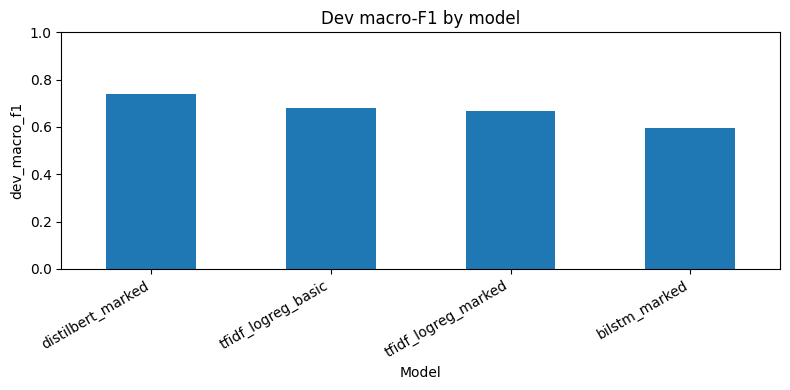

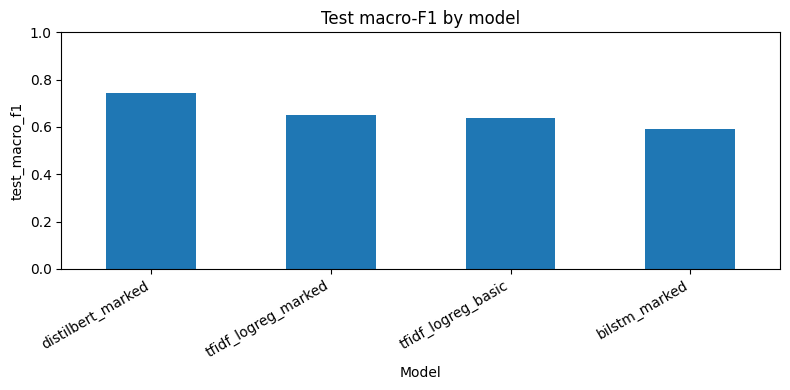

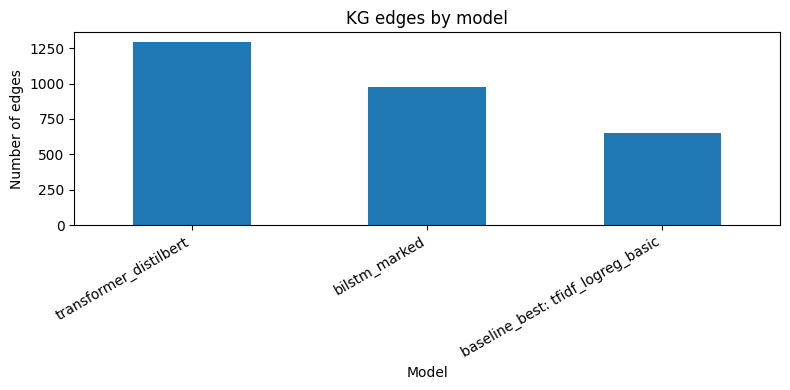

In [6]:
def plot_metric_comparison(df: pd.DataFrame, metric: str, title: str) -> None:
    """Plot one metric across all available model rows."""
    if df is None or len(df) == 0 or metric not in df.columns:
        print(f"Skipping {metric}: no comparison data available.")
        return

    plot_df = df[["model_name", metric]].dropna().copy()
    if len(plot_df) == 0:
        print(f"Skipping {metric}: all values are missing.")
        return

    plot_df = plot_df.sort_values(metric, ascending=False)
    ax = plot_df.plot(kind="bar", x="model_name", y=metric, legend=False, figsize=(8, 4))
    ax.set_title(title)
    ax.set_xlabel("Model")
    ax.set_ylabel(metric)
    ax.set_ylim(0, max(1.0, float(plot_df[metric].max()) * 1.10))
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


def plot_kg_edge_counts(df: pd.DataFrame) -> None:
    """Plot KG edge counts for each available graph output."""
    if df is None or len(df) == 0 or "num_edges" not in df.columns:
        print("Skipping KG edge-count plot: no KG comparison data available.")
        return

    plot_df = df[["model_name", "num_edges"]].dropna().copy()
    if len(plot_df) == 0:
        print("Skipping KG edge-count plot: all values are missing.")
        return

    plot_df = plot_df.sort_values("num_edges", ascending=False)
    ax = plot_df.plot(kind="bar", x="model_name", y="num_edges", legend=False, figsize=(8, 4))
    ax.set_title("KG edges by model")
    ax.set_xlabel("Model")
    ax.set_ylabel("Number of edges")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


if "model_comparison_df" in globals():
    plot_metric_comparison(model_comparison_df, "dev_macro_f1", "Dev macro-F1 by model")
    plot_metric_comparison(model_comparison_df, "test_macro_f1", "Test macro-F1 by model")
else:
    print("Run Section 17 before plotting mention-level metrics.")

if "kg_model_comparison_df" in globals():
    plot_kg_edge_counts(kg_model_comparison_df)
else:
    print("Run Section 17 before plotting KG edge counts.")
